In [1]:
import sys
sys.path.append("..")

In [43]:
import random
import numpy as np
import torch
import time
import pandas as pd
import matplotlib.pyplot as plt
import json


from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

from src.data_loader import *
from src.dataset import *
from src.collate import *
from src.bilstm import *
from src.transformer import *
from src.train import *
from src.collate import *

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

Load/Clean Dataset

In [4]:
genome = load_genome("../data/hg38.fa")
peaks = load_peaks("../data/peaks.bed")

print(f"{len(peaks)} peaks loaded.")

50260 peaks loaded.


In [5]:
dataset = build_dataset(
    peaks_df=peaks,
    genome=genome,
    context_size=200,
    max_samples=None
)

print(dataset.shape)
dataset.head()

(100520, 7)


,chrom,start,end,label,peak_seq,context_seq,full_seq
0,chr1,268011,268100,1,GCAGCAGAGGTCAGCAAGGCAAACCCGAGCCCGGGGATGCGGAGTG...,CGGGAAAGGGGGTTATTATCTAGGATCCTTGAAGCACCCCCAAGGG...,CGGGAAAGGGGGTTATTATCTAGGATCCTTGAAGCACCCCCAAGGG...
1,chr1,171644825,171644914,0,CCTGAAAGTGAACATTAATATCCCCTTTTGCAAATGAGGAAACCGA...,AGCTCTTTGCCCATTTCAAGTAATTTTTATGTAATTTTTAAATGTG...,AGCTCTTTGCCCATTTCAAGTAATTTTTATGTAATTTTTAAATGTG...
2,chr1,778620,778860,1,CCGAACACCCGCGCCTCTAACGTCGCCAACGGCCCACCTCTATGGT...,GAAGGGTCCTCCCGCCTCGGCCGCGCCAGACATAGTTTTCTATTTT...,GAAGGGTCCTCCCGCCTCGGCCGCGCCAGACATAGTTTTCTATTTT...
3,chr1,29885207,29885447,0,GGTCTCCCTTTGGGCAATGCTCTTTAACCCTTCTCTTCCTCCCTTC...,TAGTAGCCAGTTGTTAGCCCCTTCCTGTGTGCTGTCTTACAACTGC...,TAGTAGCCAGTTGTTAGCCCCTTCCTGTGTGCTGTCTTACAACTGC...
4,chr1,827440,827600,1,ACTGCGTGGCTGGGTTTGGCCACAAAAAGCGGAGGGCACTCACCCG...,GAGAACTAGGGTGGAAGGGCCGGACAGGGGCGACCTCAGTGACGGA...,GAGAACTAGGGTGGAAGGGCCGGACAGGGGCGACCTCAGTGACGGA...


In [6]:
print(dataset["label"].value_counts())

print("\nPeak lengths:")
print(dataset["peak_seq"].str.len().describe())

print("\nContext lengths:")
print(dataset["context_seq"].str.len().describe())

print("\nFull lengths:")
print(dataset["full_seq"].str.len().describe())

label
1    50260
0    50260
Name: count, dtype: int64

Peak lengths:
count    100520.000000
mean        205.130103
std          88.439032
min          21.000000
25%         143.000000
50%         200.000000
75%         260.000000
max        1080.000000
Name: peak_seq, dtype: float64

Context lengths:
count    100520.0
mean        400.0
std           0.0
min         400.0
25%         400.0
50%         400.0
75%         400.0
max         400.0
Name: context_seq, dtype: float64

Full lengths:
count    100520.000000
mean        605.130103
std          88.439032
min         421.000000
25%         543.000000
50%         600.000000
75%         660.000000
max        1480.000000
Name: full_seq, dtype: float64


In [14]:
(dataset["full_seq"].str.contains("N")).sum()

np.int64(0)

In [15]:
#remove ambiguos sequences
dataset = dataset[
    ~dataset["full_seq"].str.contains("N")
]


print(dataset.shape)
print(dataset["label"].value_counts())

(98546, 7)
label
1    50255
0    48291
Name: count, dtype: int64


In [9]:
save_path = "../data/dataset.csv"

save_dataset(dataset, save_path)

Dataset saved to ../data/dataset.csv with 98546 samples.


Split into Train/Val/Test

In [8]:
train_df, temp_df = train_test_split(dataset, test_size=0.2, random_state=42, stratify=dataset["label"])

val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"])

print(len(train_df), len(val_df), len(test_df))


78836 9855 9855


In [11]:
save_dataset(train_df, "../data/train.csv")
save_dataset(val_df, "../data/val.csv")
save_dataset(test_df, "../data/test.csv")

Dataset saved to ../data/train.csv with 78836 samples.
Dataset saved to ../data/val.csv with 9855 samples.
Dataset saved to ../data/test.csv with 9855 samples.


Train Models

In [16]:
batch_size = 128
lr = 1e-3
num_epochs = 10

In [17]:
#for testing purposes
train_small = train_df.sample(512, random_state=42)
val_small = val_df.sample(128, random_state=42)

In [18]:
outputs = {}

sequence_types = [
    "peak_seq",
    "context_seq",
    "full_seq"
]

model_types = [
    "BiLSTM",
    "Transformer"
]

In [19]:
skip = {
    ("BiLSTM", "peak_seq"),
    ("BiLSTM", "context_seq"),
    ("BiLSTM", "full_seq")
}

In [ ]:
for model_name in model_types:
    outputs[model_name] = {}

    for seq_type in sequence_types:
        if (model_name, seq_type) in skip:
            print(f"Skipping {model_name} | {seq_type}")
            continue

        print(f"{model_name} | {seq_type}")

        train_dataset = DNADataset(
            train_df,
            seq_type=seq_type
        )

        val_dataset = DNADataset(
            val_df,
            seq_type=seq_type
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            collate_fn=collate_fn
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            collate_fn=collate_fn
        )

        if model_name == "BiLSTM":
            model = BiLSTMClassifier()
        else:
            model = TransformerClassifier()
        
        criterion = nn.BCEWithLogitsLoss()
        
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr
        )

        model, history, best_val_auc = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            num_epochs=num_epochs
        )

        outputs[model_name][seq_type] = {
            "model": model,
            "history": history,
            "best_val_acc": max(history["val_acc"]),
            "best_val_auc": best_val_auc
        }
        print()

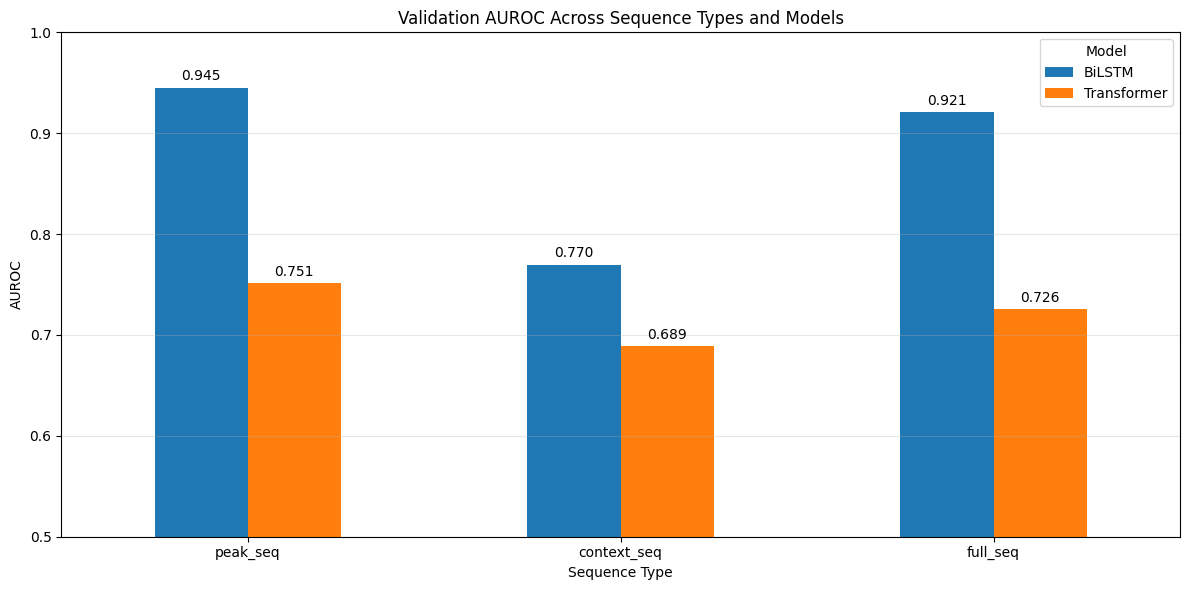

In [50]:
df = pd.read_csv("../results/data/results_summary.csv")

pivot = df.pivot(index="sequence_type", columns="model", values="best_val_auc")

order = ["peak_seq", "context_seq", "full_seq"]
pivot = pivot.reindex(order)

ax = pivot.plot(kind="bar", figsize=(12, 6))

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.title("Validation AUROC Across Sequence Types and Models")
plt.ylabel("AUROC")
plt.xlabel("Sequence Type")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=0)

plt.legend(title="Model")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig("combined_auc_bar.png", dpi=300, bbox_inches="tight")

plt.show()

In [47]:
with open("../results/data/training_histories.json", "r") as f:
    history = json.load(f)

sequence_types = ["peak_seq", "context_seq", "full_seq"]

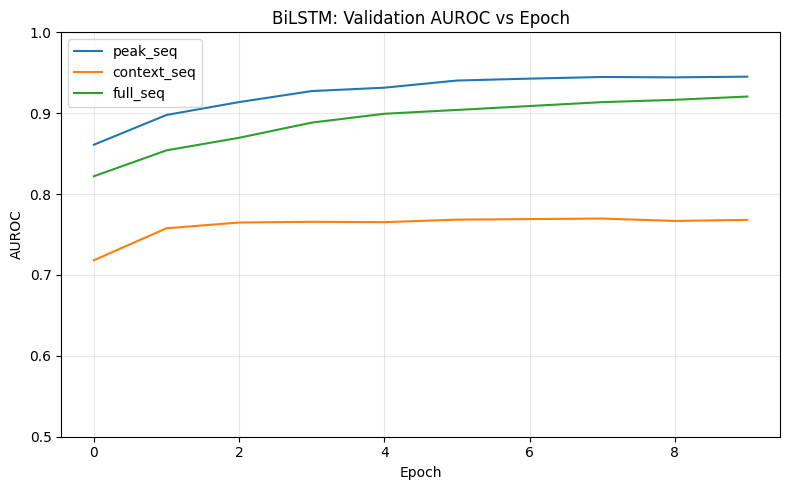

In [48]:
plt.figure(figsize=(8, 5))

for seq in sequence_types:
    vals = history["BiLSTM"][seq]["val_auc"]
    plt.plot(vals, label=seq)

plt.title("BiLSTM: Validation AUROC vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.ylim(0.5, 1.0)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("bilstm_val_auc.png", dpi=300, bbox_inches="tight")
plt.show()

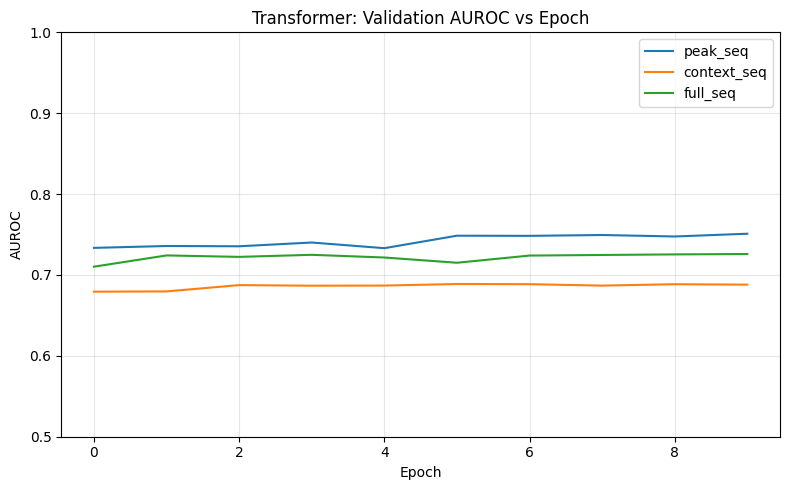

In [49]:
plt.figure(figsize=(8, 5))

for seq in sequence_types:
    vals = history["Transformer"][seq]["val_auc"]
    plt.plot(vals, label=seq)

plt.title("Transformer: Validation AUROC vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.ylim(0.5, 1.0)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("transformer_val_auc.png", dpi=300, bbox_inches="tight")
plt.show()

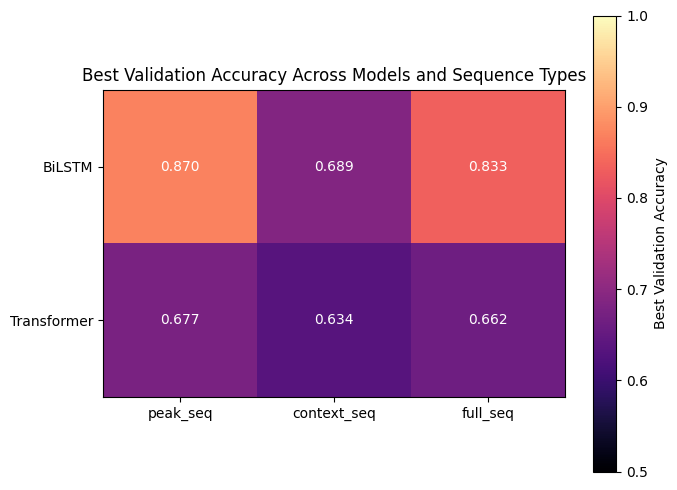

In [54]:
df = pd.read_csv("../results/data/results_summary.csv")

pivot = df.pivot(index="model", columns="sequence_type", values="best_val_acc")

order = ["peak_seq", "context_seq", "full_seq"]
pivot = pivot[order]

plt.figure(figsize=(7, 5))
plt.imshow(pivot.values, cmap="magma", vmin=0.5, vmax=1.0)

plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=0)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.colorbar(label="Best Validation Accuracy")
plt.title("Best Validation Accuracy Across Models and Sequence Types")

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        plt.text(j, i, f"{pivot.iloc[i, j]:.3f}",
                 ha="center", va="center", color="white")

plt.tight_layout()
plt.show()